In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
price = pd.read_csv("../data/forex_price_data.csv")
mc = pd.read_csv("../data/mc_scenarios.csv")
trade = pd.read_csv("../data/trade_log.csv")

print("Price Data Shape:", price.shape)
print("Monte Carlo Shape:", mc.shape)
print("Trade Log Shape:", trade.shape)

Price Data Shape: (500, 9)
Monte Carlo Shape: (1000, 8)
Trade Log Shape: (150, 15)


In [3]:
price["DateTime"] = pd.to_datetime(price["DateTime"])

price.head()

,DateTime,PairID,PairName,Open,High,Low,Close,Volume,Spread
0,2023-01-01 00:00:00,1,EUR/USD,1.08103,1.08103,1.08019,1.08054,2651,0.9
1,2023-01-01 01:00:00,1,EUR/USD,1.08010,1.08043,1.07974,1.08028,2292,1.0
2,2023-01-01 02:00:00,1,EUR/USD,1.08036,1.08158,1.07961,1.08054,1796,1.2
3,2023-01-01 03:00:00,1,EUR/USD,1.08068,1.08126,1.07973,1.08088,4019,1.4
4,2023-01-01 04:00:00,1,EUR/USD,1.08042,1.08042,1.07967,1.08030,2207,1.6


In [4]:
price.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  500 non-null    datetime64[us]
 1   PairID    500 non-null    int64         
 2   PairName  500 non-null    str           
 3   Open      500 non-null    float64       
 4   High      500 non-null    float64       
 5   Low       500 non-null    float64       
 6   Close     500 non-null    float64       
 7   Volume    500 non-null    int64         
 8   Spread    500 non-null    float64       
dtypes: datetime64[us](1), float64(5), int64(2), str(1)
memory usage: 35.3 KB


In [5]:
price.describe()

,DateTime,PairID,Open,High,Low,Close,Volume,Spread
count,500,500.0,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2023-01-11 09:30:00,1.0,1.088002,1.088494,1.087540,1.088007,3368.230000,1.405600
min,2023-01-01 00:00:00,1.0,1.065410,1.065900,1.064320,1.065750,788.000000,0.800000
25%,2023-01-06 04:45:00,1.0,1.074313,1.074982,1.073948,1.074315,2173.000000,1.100000
50%,2023-01-11 09:30:00,1.0,1.083095,1.083570,1.082685,1.082990,2990.000000,1.400000
75%,2023-01-16 14:15:00,1.0,1.104668,1.104963,1.104078,1.104763,4056.750000,1.700000
max,2023-01-21 19:00:00,1.0,1.118660,1.118660,1.117880,1.118130,13023.000000,2.000000
std,NaN,0.0,0.015255,0.015222,0.015234,0.015236,1697.493162,0.358756


In [6]:
price.isnull().sum()

DateTime    0
PairID      0
PairName    0
Open        0
High        0
Low         0
Close       0
Volume      0
Spread      0
dtype: int64

In [7]:
price["PairName"].value_counts()

PairName
EUR/USD    500
Name: count, dtype: int64

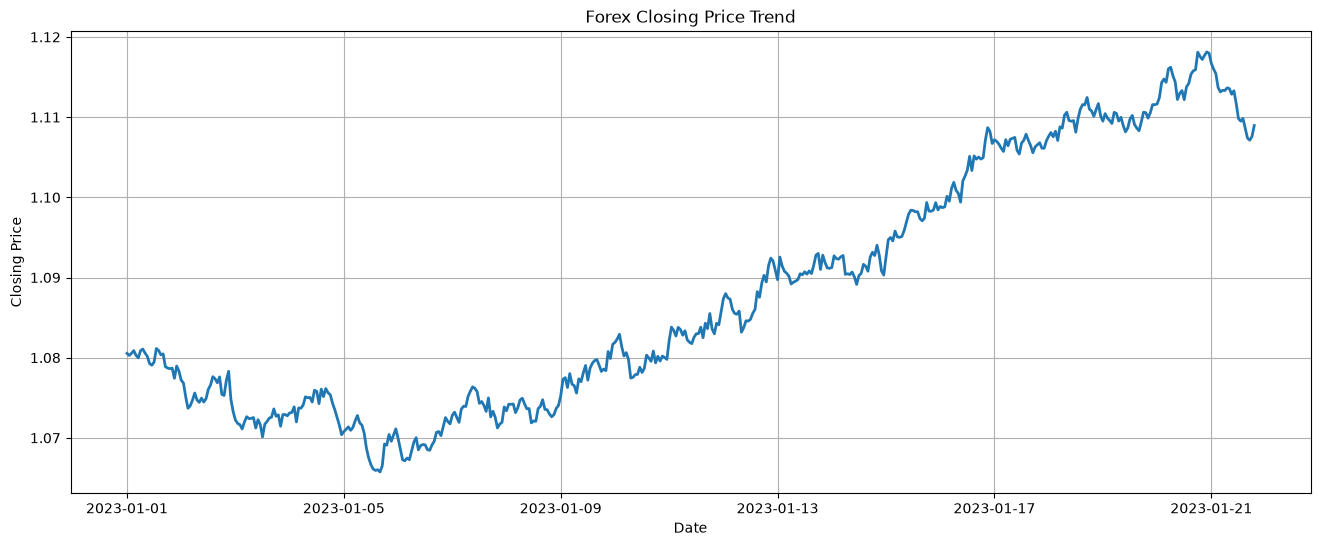

In [8]:
plt.figure(figsize=(16,6))

plt.plot(price["DateTime"], price["Close"], linewidth=2)

plt.title("Forex Closing Price Trend")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.grid(True)

plt.show()

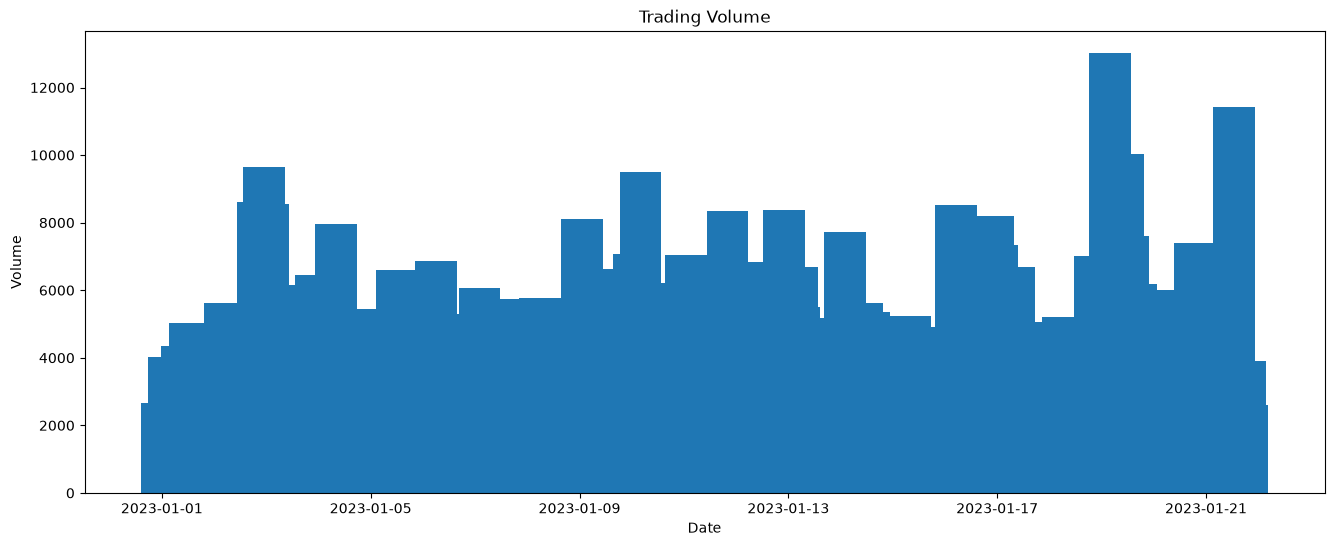

In [9]:
plt.figure(figsize=(16,6))

plt.bar(price["DateTime"], price["Volume"])

plt.title("Trading Volume")

plt.xlabel("Date")

plt.ylabel("Volume")

plt.show()

In [10]:
# Calculate 5-period Moving Average

price["MA_5"] = price["Close"].rolling(window=5).mean()

price[["DateTime", "Close", "MA_5"]].head(10)

,DateTime,Close,MA_5
0,2023-01-01 00:00:00,1.08054,NaN
1,2023-01-01 01:00:00,1.08028,NaN
2,2023-01-01 02:00:00,1.08054,NaN
3,2023-01-01 03:00:00,1.08088,NaN
4,2023-01-01 04:00:00,1.08030,1.080508
5,2023-01-01 05:00:00,1.07998,1.080396
6,2023-01-01 06:00:00,1.08087,1.080514
7,2023-01-01 07:00:00,1.08108,1.080622
8,2023-01-01 08:00:00,1.08058,1.080562
9,2023-01-01 09:00:00,1.08017,1.080536


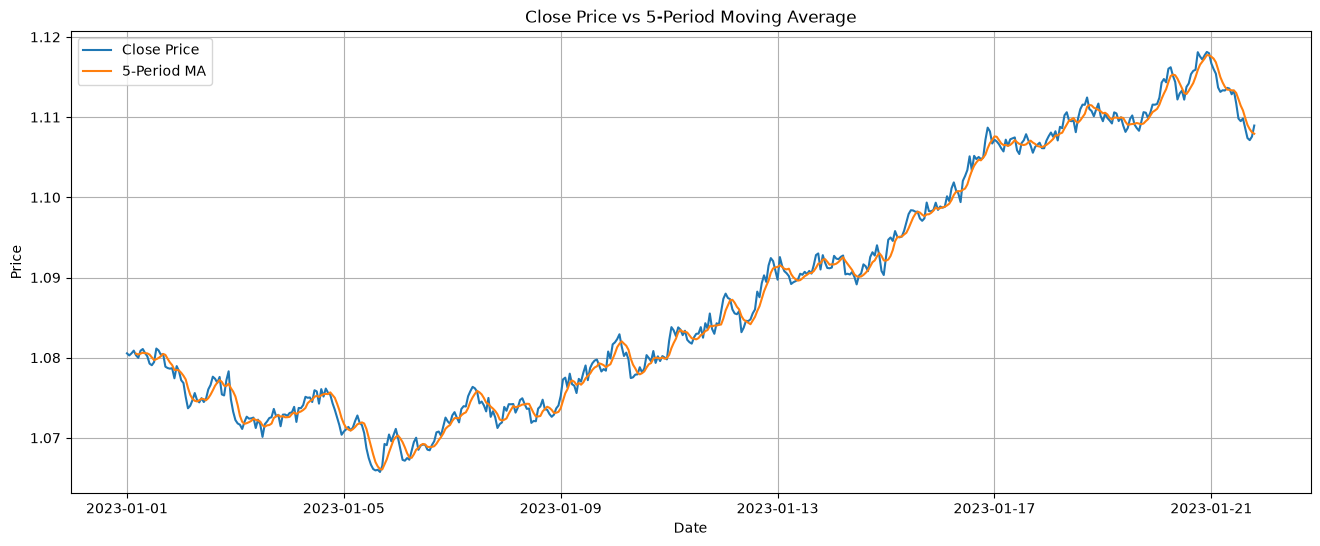

In [11]:
plt.figure(figsize=(16,6))

plt.plot(price["DateTime"], price["Close"], label="Close Price")

plt.plot(price["DateTime"], price["MA_5"], label="5-Period MA")

plt.title("Close Price vs 5-Period Moving Average")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

In [12]:
# Calculate 20-period Moving Average

price["MA_20"] = price["Close"].rolling(window=20).mean()

price[["DateTime","Close","MA_5","MA_20"]].tail(20)

,DateTime,Close,MA_5,MA_20
480,2023-01-21 00:00:00,1.11670,1.117538,1.115541
481,2023-01-21 01:00:00,1.11600,1.117300,1.115540
482,2023-01-21 02:00:00,1.11542,1.116844,1.115499
483,2023-01-21 03:00:00,1.11369,1.115956,1.115426
484,2023-01-21 04:00:00,1.11315,1.114992,1.115363
485,2023-01-21 05:00:00,1.11335,1.114322,1.115421
486,2023-01-21 06:00:00,1.11332,1.113786,1.115439
487,2023-01-21 07:00:00,1.11365,1.113432,1.115456
488,2023-01-21 08:00:00,1.11356,1.113406,1.115525
489,2023-01-21 09:00:00,1.11285,1.113346,1.115479


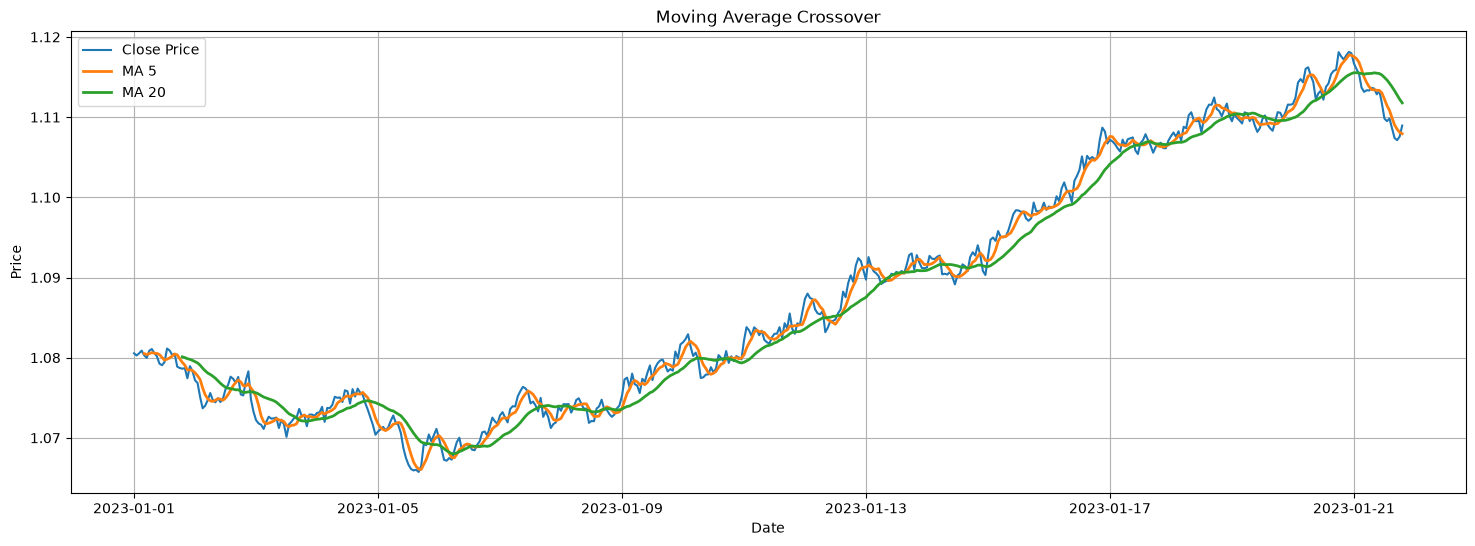

In [13]:
plt.figure(figsize=(18,6))

plt.plot(price["DateTime"], price["Close"], label="Close Price")

plt.plot(price["DateTime"], price["MA_5"], label="MA 5", linewidth=2)

plt.plot(price["DateTime"], price["MA_20"], label="MA 20", linewidth=2)

plt.title("Moving Average Crossover")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

In [14]:
import numpy as np

# Default signal
price["Signal"] = "HOLD"

# Buy signal
price.loc[price["MA_5"] > price["MA_20"], "Signal"] = "BUY"

# Sell signal
price.loc[price["MA_5"] < price["MA_20"], "Signal"] = "SELL"

price[["DateTime", "Close", "MA_5", "MA_20", "Signal"]].tail(20)

,DateTime,Close,MA_5,MA_20,Signal
480,2023-01-21 00:00:00,1.11670,1.117538,1.115541,BUY
481,2023-01-21 01:00:00,1.11600,1.117300,1.115540,BUY
482,2023-01-21 02:00:00,1.11542,1.116844,1.115499,BUY
483,2023-01-21 03:00:00,1.11369,1.115956,1.115426,BUY
484,2023-01-21 04:00:00,1.11315,1.114992,1.115363,SELL
485,2023-01-21 05:00:00,1.11335,1.114322,1.115421,SELL
486,2023-01-21 06:00:00,1.11332,1.113786,1.115439,SELL
487,2023-01-21 07:00:00,1.11365,1.113432,1.115456,SELL
488,2023-01-21 08:00:00,1.11356,1.113406,1.115525,SELL
489,2023-01-21 09:00:00,1.11285,1.113346,1.115479,SELL


In [15]:
price["Signal"].value_counts()

Signal
BUY     315
SELL    166
HOLD     19
Name: count, dtype: int64

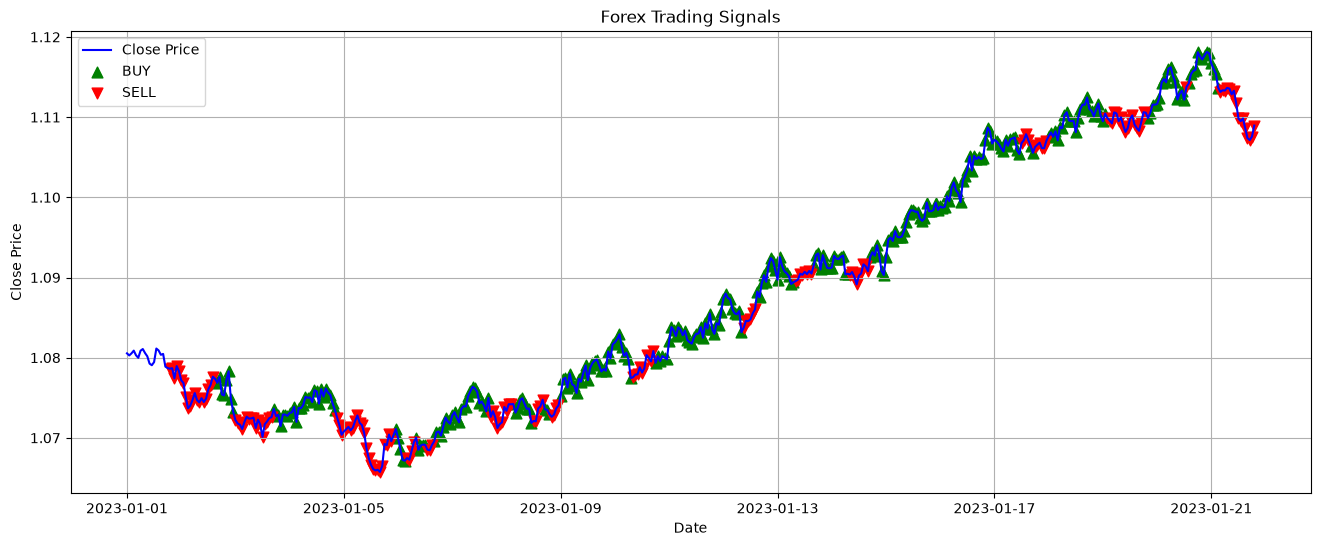

In [16]:
plt.figure(figsize=(16,6))

plt.plot(price["DateTime"], price["Close"], label="Close Price", color="blue")

buy = price[price["Signal"] == "BUY"]
sell = price[price["Signal"] == "SELL"]

plt.scatter(buy["DateTime"], buy["Close"], marker="^", color="green", label="BUY", s=60)

plt.scatter(sell["DateTime"], sell["Close"], marker="v", color="red", label="SELL", s=60)

plt.title("Forex Trading Signals")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.legend()

plt.grid(True)

plt.show()

In [17]:
# Convert BUY/SELL/HOLD into numbers

price["Signal_Num"] = price["Signal"].map({
    "BUY":1,
    "SELL":0,
    "HOLD":2
})

price[["Signal","Signal_Num"]].head(10)

,Signal,Signal_Num
0,HOLD,2
1,HOLD,2
2,HOLD,2
3,HOLD,2
4,HOLD,2
5,HOLD,2
6,HOLD,2
7,HOLD,2
8,HOLD,2
9,HOLD,2


In [18]:
features = price[[
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Spread",
    "MA_5",
    "MA_20"
]]

target = price["Signal_Num"]

features.head()

,Open,High,Low,Close,Volume,Spread,MA_5,MA_20
0,1.08103,1.08103,1.08019,1.08054,2651,0.9,NaN,NaN
1,1.08010,1.08043,1.07974,1.08028,2292,1.0,NaN,NaN
2,1.08036,1.08158,1.07961,1.08054,1796,1.2,NaN,NaN
3,1.08068,1.08126,1.07973,1.08088,4019,1.4,NaN,NaN
4,1.08042,1.08042,1.07967,1.08030,2207,1.6,1.080508,NaN


In [19]:
data = price.dropna().copy()

X = data[[
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Spread",
    "MA_5",
    "MA_20"
]]

y = data["Signal_Num"]

print(X.shape)
print(y.shape)

(481, 8)
(481,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(384, 8)
(97, 8)
